In [1]:
# %pip install --quiet rawpy exifread requests tqdm opencv-python matplotlib numpy

In [ ]:
# %pip install pympler

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.8/165.8 kB 13.3 MB/s eta 0:00:00


## Imports

In [1]:
import json
import random
from pathlib import Path
import rawpy
import exifread
import cv2
import numpy as np
import requests
from tqdm.auto import tqdm
import tifffile, collections
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor
from concurrent.futures import ProcessPoolExecutor
import multiprocessing as mp
import pandas as pd

/home/damien/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from acr_tone import finish

## GLOBAL PARAMS

In [28]:
DATA_DIR = Path("/home/damien/data_fivek_dng")
DNG_DIR = DATA_DIR / "dng"
OUT_DIR = DATA_DIR / "dataset_soomin"
# VAL_DIR = DATA_DIR / "simulated_3"/"val"
for d in (DNG_DIR, OUT_DIR):
    d.mkdir(parents=True, exist_ok=True)

N_WORKERS = 16
N_OUTDOOR = 2513       # nb of outdoor to get
N_INDOOR = 748         # nb of DNG "indoor"
N_EXAMPLES = 50_000      # nb of examples to simulate (m, t, r, c) 
JPEG_QUALITY = 95      # jpeg quality
SAVE_LINEAR = True    # True to save .npz sRGB linear
PATCH = 224 # 512            # 256p like in the paper
TAU = 0.1329           # exposition objectif of the mean pixel (Func. S1)
SEED = 1009
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
rng = np.random.default_rng(SEED)
rnd = random.Random(SEED)


## UTILS

In [4]:
DNG = {"ColorMatrix1": 0xC621, "ColorMatrix2": 0xC622,
    "CameraCalibration1": 0xC623, "CameraCalibration2": 0xC624,
    "AnalogBalance": 0xC627, "AsShotNeutral": 0xC628, "AsShotWhiteXY": 0xC629,
    "CalibrationIlluminant1": 0xC65A, "CalibrationIlluminant2": 0xC65B}


NOMS = {0xC621:"ColorMatrix1", 0xC622:"ColorMatrix2", 0xC623:"CameraCalibration1",
    0xC624:"CameraCalibration2", 0xC627:"AnalogBalance", 0xC628:"AsShotNeutral",
    0xC629:"AsShotWhiteXY", 0xC65A:"CalibrationIlluminant1",
    0xC65B:"CalibrationIlluminant2", 0xC65C:"BestQualityScale"}

_FLIP = {
    0: lambda a: a,                     # no rotation
    3: lambda a: a[::-1, ::-1],         # 180°
    5: lambda a: np.rot90(a, 1),        # 90° anticlockwise
    6: lambda a: np.rot90(a, -1),       # 90° clockwise
}


def dng_tag(tags, name):
    """Lit un tag DNG. exifread ne les nomme pas : on passe par l'ID hexa."""
    t = tags.get("Image Tag 0x%04X" % DNG[name])
    if t is None:
        return None
    out = []
    for v in t.values:
        out.append(float(v.num) / float(v.den) if hasattr(v, "num") else float(v))
    return np.array(out, np.float64)
def exif_tag(tags, name):
    """EXIF standard."""
    t = tags.get(name)
    if t is None or not t.values:
        return None
    v = t.values[0]
    return float(v.num) / float(v.den) if hasattr(v, "num") else float(v)

def reject_noms(dng_file):
        with open(dng_file[0], "rb") as f:
            tags = exifread.process_file(f, details=False)
        asshot = dng_tag(tags,"AsShotNeutral")
        whitexy = dng_tag(tags, "AsShotWhiteXY")
        exif = exif_tag(tags, "EXIF FNumber")
        if asshot is None and whitexy is None:
            return False
        if exif is None:
            return False
        return True
            

## DOWNLOADING DATA (NOTEBOOK)

In [5]:
META_URL = "https://huggingface.co/datasets/yuukicammy/MIT-Adobe-FiveK/raw/main/training.json"

meta_path = DATA_DIR / "training.json"
if not meta_path.exists():
    resp = requests.get(META_URL, timeout=120)
    resp.raise_for_status()
    meta_path.write_bytes(resp.content)
metadata = json.loads(meta_path.read_text())
print(f"{len(metadata)} images référencées")

by_loc = {}
for name, item in metadata.items():
    loc = item.get("categories", {}).get("location", "unknown")
    by_loc.setdefault(loc, []).append((name, item))
print({k: len(v) for k, v in sorted(by_loc.items())})

selection = []
for loc, n in [("outdoor", N_OUTDOOR), ("indoor", N_INDOOR)]:
    items = list(by_loc.get(loc, []))
    rnd.shuffle(items)
    selection += [(name, item, loc) for name, item in items[:n]]


def download_dng(name, item):
    url = item["urls"]["dng"].replace("http://", "https://")
    path = DNG_DIR / f"{name}.dng"
    if path.exists() and path.stat().st_size > 0:
        return path
    with requests.get(url, stream=True, timeout=300) as resp:
        resp.raise_for_status()
        tmp = path.with_suffix(".part")
        with open(tmp, "wb") as f:
            for chunk in resp.iter_content(1 << 20):
                f.write(chunk)
        tmp.rename(path)
    return path


dng_files = []  
for name, item, loc in tqdm(selection, desc="DNG"):
    try:
        dng_file = ((download_dng(name, item), loc,
                          item.get("categories", {})))
        # making sure to get images with the right metadata
        bool = reject_noms(dng_file)
        if bool:
            dng_files.append(dng_file)
    except Exception as exc:
        print(f"échec {name}: {exc}")

total_mb = sum(p.stat().st_size for p, _, _ in dng_files) / 1e6
print(f"{len(dng_files)} DNG prêts ({total_mb:.0f} Mo)")


3500 images référencées
{'indoor': 748, 'outdoor': 2513, 'unknown': 239}


DNG: 100%|██████████| 3261/3261 [00:03<00:00, 936.65it/s]

3158 DNG prêts (30981 Mo)


###  Je dois enlever lui "dng/a4246-Duggan_090330_6226.part"

## TESTS 

Big difference between Rawpy and adobe SNK processing is with opcodes that we don't find in our dataset, so both methods are similar here.

In [5]:
import tifffile, collections

OPCODES = {51008: "OpcodeList1", 51009: "OpcodeList2", 51022: "OpcodeList3"}
hits = collections.Counter()
for p, *_ in dng_files[:50]:
    with tifffile.TiffFile(str(p)) as tif:
        for page in list(tif.pages) + [sub for pg in tif.pages for sub in (pg.pages or [])]:
            for code, name in OPCODES.items():
                if code in page.tags:
                    hits[name] += 1
print(hits or "aucun opcode -> LibRaw ≈ ACR étapes 1-4 sur ce dataset")

aucun opcode -> LibRaw ≈ ACR étapes 1-4 sur ce dataset


Tester si y'a -1 comme size.flip dans le dataset

## Calculating WhiteXY, Interpolation of ColorMatrix1/2, xy space and XYZ space

<strong style="color: green;">CLEARED</strong>, I'm sure about this one

In [6]:


# temperatures of the normalized illuminants (EXIF LightSource, spec DNG ch. 6)
ILLUMINANT_TEMP = {1: 6504., 2: 4100., 3: 2856., 4: 5500., 9: 5500., 10: 6504.,
                   11: 7504., 12: 6430., 13: 5050., 14: 4150., 15: 3450.,
                   17: 2856., 18: 4874., 19: 6774., 20: 5503., 21: 6504.,
                   22: 7504., 23: 5003., 24: 3200.}
# ------------------------------------------------------- xy -> temperature
def xy_to_temp(xy):
    """CCT par l'approximation de McCamy (1992). L'ecart a la methode de
    Robertson de la spec DNG est de quelques kelvins pres du lieu planckien."""
    x, y = float(xy[0]), float(xy[1])
    n = (x - 0.3320) / (0.1858 - y + 1e-12)
    return 449.0 * n ** 3 + 3525.0 * n ** 2 + 6823.3 * n + 5520.33


# ------------------------------------------- Func. S7 : XYZ -> camera pour un xy
def find_xyz_to_camera(xy, cal):
    """Interpole entre les deux matrices de calibration selon la temperature
    du point blanc vise. L'interpolation se fait en 1/T (mireds), pas en T."""
    t1, t2 = cal["temp1"], cal["temp2"]
    cm1, cm2 = cal["cm1"], cal["cm2"]
    cc1, cc2 = cal["cc1"], cal["cc2"]
    if cm2 is None:                                  # une seule calibration
        cm, cc = cm1, cc1
    else:
        temp = xy_to_temp(xy)
        if temp <= min(t1, t2):
            g = 1.0 if t1 <= t2 else 0.0
        elif temp >= max(t1, t2):
            g = 0.0 if t1 <= t2 else 1.0
        else:
            g = (1.0 / temp - 1.0 / t2) / (1.0 / t1 - 1.0 / t2)
        cm = g * cm1 + (1.0 - g) * cm2
        cc = g * cc1 + (1.0 - g) * cc2
    return cal["ab"] @ cc @ cm                       # AB . CC . CM


# ------------------------------- Func. S3 : AsShotNeutral -> xy (point fixe)
def neutral_to_xy(neutral, cal, n_iter=30, tol=1e-9):
    """La matrice depend du point blanc, qui depend de la matrice : on itere.
    Depart a D50, comme la spec DNG."""
    xy = np.array([0.34567, 0.35850])                # D50
    for _ in range(n_iter):
        xyz = np.linalg.solve(find_xyz_to_camera(xy, cal), neutral)
        new = np.array([xyz[0], xyz[1]]) / max(xyz.sum(), 1e-12)
        if np.abs(new - xy).max() < tol:
            return new, True
        xy = new
    return xy, False

def read_calibration(path):
    """getting what Func. S7. needs"""
    with open(path, "rb") as f:
        tags = exifread.process_file(f, details=False)
    ashot = dng_tag(tags, "AsShotNeutral")
    cm1 = dng_tag(tags, "ColorMatrix1")
    cm2 = dng_tag(tags, "ColorMatrix2")
    cc1 = dng_tag(tags, "CameraCalibration1")
    cc2 = dng_tag(tags, "CameraCalibration2")
    il1 = dng_tag(tags, "CalibrationIlluminant1")
    il2 = dng_tag(tags, "CalibrationIlluminant2")
    ab = dng_tag(tags, "AnalogBalance")
    eye = np.eye(3)
    cal = {"cm1": cm1.reshape(3, 3),
           "cm2": None if cm2 is None else cm2.reshape(3, 3),
           "cc1": eye if cc1 is None else cc1.reshape(3, 3),
           "cc2": eye if cc2 is None else cc2.reshape(3, 3),
           "ab": eye if ab is None else np.diag(ab),
           "temp1": ILLUMINANT_TEMP.get(int(il1[0]) if il1 is not None else 17, 2856.),
           "temp2": ILLUMINANT_TEMP.get(int(il2[0]) if il2 is not None else 21, 6504.), "ashot": ashot}
    return cal, tags

# ------------------------------------------------------------- Func. S3
def compute_white_xy(path):
    """WhitePoint in xy. Use AsShotWhiteXY if it exists, uses otherwise
    AsShotNeutral.Both are present in our current filtered DATASET."""
    cal, tags = read_calibration(path)
    xy = dng_tag(tags, "AsShotWhiteXY")

    if xy is not None:
        return np.asarray(xy[:2], np.float64), "AsShotWhiteXY", True

    neutral = dng_tag(tags, "AsShotNeutral")
    # if neutral is None:
    #     raise ValueError("ni AsShotWhiteXY ni AsShotNeutral dans %s" % path)
    
    xy, ok = neutral_to_xy(neutral[:3], cal)
    return xy, "AsShotNeutral", ok

def xy_to_xyz(xy, Y=1.0):
    """Chromaticity -> tristimulus, Luminance = Y = 1."""
    x, y = float(xy[0]), float(xy[1])
    return np.array([Y * x / y, Y, Y * (1.0 - x - y) / y])

def camera_to_xyz(path):
    """Matrice CAM -> XYZ (Func. S3 l.5-7) and WhitePoint as-shot."""
    cal, tags = read_calibration(path)
    xy = dng_tag(tags, "AsShotWhiteXY")
    if xy is not None:
        xy, ok = np.asarray(xy[:2], np.float64), True
    else:
        neutral = dng_tag(tags, "AsShotNeutral")
        # if neutral is None:
        #     raise ValueError(f"ni AsShotWhiteXY ni AsShotNeutral dans {path}")
        xy, ok = neutral_to_xy(neutral[:3], cal)
        if not ok:
            print(f"NeutralToXY n'a pas convergé: {path}")
    return np.linalg.inv(find_xyz_to_camera(xy, cal)).astype(np.float32), xy

# XYZ -> CAM :  M = find_xyz_to_camera(xy, cal)
# CAM -> XYZ:   inv(M)

## RAW IMAGE PROCESSING

<strong style="color: GREEN;"> CLEARED</strong>

In [7]:
def clip_level(raw, min_pixels=64):
    """Plus bas des deux plafonds : le plateau réel du capteur, et le white_level
    au-dessus duquel LibRaw aplatit tout dans postprocess. Pas de plateau
    détecté -> pas d'écrêtage capteur -> seul le plafond LibRaw compte."""
    wl  = float(raw.white_level)
    vis = raw.raw_image_visible
    mx  = int(vis.max())
    if int((vis >= mx - 1).sum()) >= min_pixels:
        return min(wl, float(mx))
    return wl


read_raw_to_xyz is complicated and I need to find what to do with my white level, where my saturation mask acts

In [8]:
def read_exposure(path):
    """Exposition e = s * g / n**2 (Sec. 3.1 du papier)."""
    with open(path, "rb") as f:
        tags = exifread.process_file(f, details=False)

    def tag(name, default):
        t = tags.get(name)
        if t is None or not t.values:
            print(f"Il manque la valeur {name}")
            return default, False
        v = t.values[0]
        try:
            return float(v.num) / float(v.den), True
        except AttributeError:
            return float(v), True

    s, bool_s = tag("EXIF ExposureTime", 1 / 60)         
    n, bool_n = tag("EXIF FNumber", 4.0)         
    g, bool_g = tag("EXIF ISOSpeedRatings", 100.0)       
    return s * g / max(n, 0.7) ** 2, bool_s * bool_n * bool_g

_PP = dict(gamma=(1, 1), no_auto_bright=True, adjust_maximum_thr=0, output_bps=16,
           use_camera_wb=False, use_auto_wb=False, user_wb=[1.0, 1.0, 1.0, 1.0],
           output_color=rawpy.ColorSpace.raw)


def align_mask(path, sat_b, **pp):
    """mask : bool HxW en repère capteur -> repère `shape` (= cam.shape[:2])."""
    with rawpy.imread(str(path)) as raw:
        v = raw.raw_image_visible
        v[:] = 0
        v[sat_b] = int(raw.white_level)
        out = raw.postprocess(**pp)
        print(out.shape, out.max(-1).shape, out.max())
    return np.ascontiguousarray(out.max(-1) > 0.25 * 65535)

def align_maskv2(mask, shape, flip=0, path=None, half_size=True):
    """mask : bool HxW en repère capteur -> repère `shape` (= cam.shape[:2]).
       optimized version
    """
    h, w = mask.shape
    if (h, w) == tuple(shape):            # DNG linéaire : pas de binning côté LibRaw
        return np.ascontiguousarray(mask)

    m = np.pad(mask, ((0, h % 2), (0, w % 2)))          # ceil, comme LibRaw
    m = m.reshape(-1, 2, m.shape[1] // 2, 2).any(axis=(1, 3))
    m = _FLIP.get(flip, lambda a: a)(m)
    if m.shape == tuple(shape):
        return np.ascontiguousarray(m)
    # géométrie non affine (fuji_rotate, pixel_aspect...) : on refait passer
    # le masque dans le MEME postprocess que l'image.
    with rawpy.imread(str(path)) as raw:
        v = raw.raw_image_visible
        v[:] = np.where(mask, int(raw.white_level),0)
        out = raw.postprocess(half_size=half_size, **_PP)
    return np.ascontiguousarray(out.max(-1) > 0) #really conservative, dilating the mask a bit

def read_raw_to_xyz(path, half_size=True):
    """ACR étapes 1-4 : linearization, dématriçage, black level, -> XYZ.

    user_wb=(1,1,1,1) no white balance, we get XYZ
    "as-shot" where illuminants color is preserved.
    
    Output (xyz, illuminant_xyz, saturated, sat_bool)

    sat_bool = False for sRAW images where the bayer mask to get saturation mask makes no sense
    """
    with rawpy.imread(str(path)) as raw:
        black = np.mean(raw.black_level_per_channel)
        wl    = raw.white_level #clip_level(raw, min_pixels=64) # 
        bayer = raw.raw_image_visible
        sat_b = bayer >= black + 0.98 * (wl - black)
        if sat_b.ndim == 3:              # sRAW / DNG linear : no mosaic, I have to take them off later
            return None, None, None, False
        
        cam = raw.postprocess(
            gamma=(1, 1),
            no_auto_bright=True,
            adjust_maximum_thr=0,
            output_bps=16,
            use_camera_wb=False, 
            use_auto_wb=False, 
            user_wb=[1.0, 1.0, 1.0, 1.0],
            output_color=rawpy.ColorSpace.raw,  
            half_size=half_size,)
        saturated = align_maskv2(sat_b, cam.shape[:2], raw.sizes.flip, path)

        # ColorMatrix of DNG : XYZ -> CAM (rgb camera) ; we inverse it (step 4 ACR)
        cam_to_xyz, xy = camera_to_xyz(path)

    illum = None
    white_xyz = xy_to_xyz(xy)
    illum = white_xyz

    # output_bps=16 gives uint16: (2^16 - 1 = 65535),
    # we normalize ([0,1])/ Saturation >= 1. 
    cam = cam.astype(np.float32) / 65535.0

    # func S6.
    cam_white = np.linalg.solve(cam_to_xyz, illum)   # = inv(cam_to_xyz) @ illum
    cam_white = np.clip(cam_white / cam_white.max(), 0.001, 1.0).astype(np.float32)
    cam = np.minimum(cam, cam_white) 
    
    xyz = np.einsum("ij,hwj->hwi", cam_to_xyz, cam)
    return np.clip(xyz, 0, None), illum, saturated, True


I tested what happens to the saturation mask after resizing especially in <strong>load_pool</strong> and the maks is almost the same.
You can see the comparison in <p style="color: red;">image_raw_exp//Filter_saturation_mask_... .png</p>

### Testing about white balance

In [9]:
# def probe(path):
#     with rawpy.imread(str(path)) as raw:
#         v  = raw.raw_image_visible
#         wl = float(raw.white_level)
#         mx = int(v.max())
#         n_top = int((v >= mx - 1).sum())
#         return wl, mx, n_top / v.size, np.mean(raw.black_level_per_channel)

# for i in (2,3,5,  20,25,30, 50, 110, 140, 200):
#     p = dng_files[i][0]
#     wl, mx, frac, black = probe(p)
#     print(f"{i} wl={wl:7.0f} max={mx:6d} max/wl={mx/wl:.3f} "
#           f"px_au_max={frac:.4%} black={black:.0f}")


## COLORS and DISPLAY

<strong style="color: green;">CLEARED</strong>

In [10]:
import matplotlib.pyplot as plt

# --- Color tools  -------------------------------------------------------
D50 = np.array([0.9642, 1.0, 0.8249], np.float32)

BRADFORD = np.array([[0.8951, 0.2664, -0.1614],
                     [-0.7502, 1.7135, 0.0367],
                     [0.0389, -0.0685, 1.0296]], np.float32)


def cat_matrix(src_white, dst_white=D50):
    """Chromatic adaptation of Bradford : XYZ(illuminant src) -> XYZ(dst)."""
    s = BRADFORD @ src_white
    d = BRADFORD @ dst_white
    return (np.linalg.inv(BRADFORD) @ np.diag(d / s) @ BRADFORD).astype(np.float32)

# Standard Matrix (ICC / IEC 61966-2-1)
XYZ_D50_TO_SRGB = np.array([[3.1338561, -1.6168667, -0.4906146],
                            [-0.9787684, 1.9161415, 0.0334540],
                            [0.0719453, -0.2289914, 1.4052427]], np.float32)
XYZ_D65_TO_SRGB = np.array([[3.2404542, -1.5371385, -0.4985314],
                            [-0.9692660, 1.8760108, 0.0415560],
                            [0.0556434, -0.2040259, 1.0572252]], np.float32)


def apply_matrix(img, M):
    # return np.einsum("ij,...j->...i", M, img)
    return img @ M.T

def luminance(lin_srgb):
    return lin_srgb @ np.array([0.2126, 0.7152, 0.0722], np.float32)

def srgb_encode(x):
    """Gamma sRGB (linear [0,1] -> encoded [0,1])."""
    x = np.clip(x, 0.0, 1.0)
    return np.where(x <= 0.0031308, 12.92 * x, 1.055 * x ** (1 / 2.4) - 0.055)

def srgb_decode(x):
    """Gamma sRGB linear encoded [0,1] -> linear [0,1]
       without a tone curve, it is possible to go to linear sRGB 
    """
    return np.where(x <= 12.92 * 0.0031308, x / 12.92, ((x + 0.055) / 1.055) ** 2.4 )


# --- Display ------------------------------------------------------------
def auto_expose(lin, target=0.18):
    """Expose the mean on the gray."""
    key = float(np.exp(np.log(np.clip(luminance(lin), 1e-6, None)).mean()))
    return lin * (target / max(key, 1e-8))

def to_display(lin_srgb, ev=0.0):
    return srgb_encode(lin_srgb * 2.0 ** ev)


def xyz_to_display(xyz, illum=None, white_balance=True):
    if white_balance:
        w = illum 
        lin = apply_matrix(xyz, XYZ_D50_TO_SRGB @ cat_matrix(w))
    else:
        lin = apply_matrix(xyz, XYZ_D65_TO_SRGB)
    return np.clip(auto_expose(np.clip(lin, 0, None)), 0, 1)


def show_row(images, titles, ev=0.0, size=3.2):
    fig, axes = plt.subplots(1, len(images), figsize=(size * len(images), size))
    for ax, img, title in zip(np.atleast_1d(axes), images, titles):
        ax.imshow(to_display(img, ev))
        ax.set_title(title, fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


## PROCESSING all the RAWs in XYZ

<strong style="color: green;">CLEARED</strong>

In [11]:
def random_crop(img, size, sat, rng):
    h, w = img.shape[:2]
    C = int(min(h, w) * rng.uniform(0.4, 1.0))
    C = max(C, size)                                  # no upscale
    y = int(rng.integers(0, h - C + 1))
    x = int(rng.integers(0, w - C + 1))
    crop = np.asarray(img[y:y+C, x:x+C], np.float32)    # slicing
    out = cv2.resize(crop, (size, size), interpolation=cv2.INTER_AREA) 
    return out, float(sat[y:y+C, x:x+C].mean())

8 min for 3510 images with N_WORKERS=6  
2 min avec 16 workers

In [12]:
CACHE_DIR = DATA_DIR / "pool_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def _init_worker():
    cv2.setNumThreads(1) 
    
def _save_atomic(path, arr):
    """tmp + rename: an interrupted run never leaves a truncated .npy behind."""
    tmp = path.with_suffix(".tmp.npy")
    np.save(tmp, arr)
    tmp.rename(path)


def _convert_one(item):
    """Child process: decode to disk, return metadata only (a few hundred bytes)."""
    path, loc, cats = item
    try:
        xyz, illum, sat, ok_xyz = read_raw_to_xyz(path)
        if not ok_xyz:
            return "skip", path.stem, "sRAW / linear DNG"
        e, ok_exp = read_exposure(path)
        if not ok_exp:
            return "skip", path.stem, "missing EXIF exposure"
        _save_atomic(CACHE_DIR / f"{path.stem}.xyz.npy", xyz.astype(np.float16))
        _save_atomic(CACHE_DIR / f"{path.stem}.sat.npy", np.ascontiguousarray(sat))
        return "ok", {"name": path.stem, "loc": loc, "cats": cats, "e": e,
                      "illum": illum.tolist(), "shape": list(xyz.shape),
                      "sat_sum": int(sat.sum())}
    except Exception as exc:
        return "fail", path.stem, f"{type(exc).__name__}: {exc}"


def _attach(m):
    """Lazy view: nothing is read until a crop actually touches those pages."""
    return {**m,
            "illum": np.asarray(m["illum"], np.float64),
            "xyz": np.load(CACHE_DIR / f"{m['name']}.xyz.npy", mmap_mode="r"),
            "saturation": np.load(CACHE_DIR / f"{m['name']}.sat.npy", mmap_mode="r")}

def load_pool(files, n_workers=N_WORKERS, rebuild=False):
    index_p = CACHE_DIR / "pool_index.json"
    if index_p.exists() and not rebuild:
        meta = json.loads(index_p.read_text())
        print(f"{len(meta)} images from cache")
    else:
        meta, dropped = [], []
        ctx = mp.get_context("fork")
        with ProcessPoolExecutor(n_workers, mp_context=ctx,
                                 initializer=_init_worker) as ex:
            for res in tqdm(ex.map(_convert_one, files, chunksize=1),
                            total=len(files), desc="RAW -> XYZ"):
                (meta if res[0] == "ok" else dropped).append(
                    res[1] if res[0] == "ok" else res[1:])
        index_p.write_text(json.dumps(meta))
        print(f"{len(meta)} kept, {len(dropped)} dropped")
        for name, why in dropped[:10]:
            print("  -", name, why)
    return [_attach(m) for m in meta]
pool = load_pool(dng_files, rebuild=False)

3152 images from cache


## Reflection Simulation

<strong style="color: orange;"> less CLEARED</strong>

- GLASS_IOR has to be chosen uniformly
- SENSOR 

In [13]:
GLASS_IOR = 1.52      # refraction value for glass, we have to take this uniform
# SENSOR_W = 0.036      # capteur plein format (m) (format donnant le + de flou) capteur plein format 36x24 mm
# explains why a phone is sharp (small sized sensor; check formula of defocus blur)
SENSOR_full_min = 0.024
SENSOR_W = SENSOR_full_min
SENSOR_APS_C_min  = 0.0157
# We can imagine simuling a few SENSORS (not only aps_c), the main SENSOR of MIT5k is APS-C, 
# but we can simulate other SENSORS
# we take the min cause we have a squared 256x256 / PATCHxPATCH, if we want 3/2 images format we keep SENSOR_W=0.036 m
def _fresnel_single(cos_i, n=GLASS_IOR):
    """Fresnel non polarized, interface air->glass."""
    cos_i = np.clip(cos_i, 1e-6, 1.0)
    sin_t = np.sqrt(np.clip(1 - cos_i ** 2, 0, 1)) / n
    cos_t = np.sqrt(np.clip(1 - sin_t ** 2, 0, 1))
    rs = ((cos_i - n * cos_t) / (cos_i + n * cos_t)) ** 2
    rp = ((n * cos_i - cos_t) / (n * cos_i + cos_t)) ** 2
    return 0.5 * (rs + rp)

def fresnel_angle(theta_i, n=GLASS_IOR):
    """
    Fresnel Formula (paper), same results as _fresnel_single
    """
    theta_i = theta_i * np.pi/180
    theta_ip = np.arcsin(np.sin(theta_i)/n)
    sum = theta_i + theta_ip
    substrat = theta_i - theta_ip
    rs = (np.sin(substrat)/np.sin(sum))**2
    rp = (np.tan(substrat)/np.tan(sum))**2
    return (rs + rp) * 0.5

def fresnel_reflectance(R, n=GLASS_IOR):
    """glass with 2 interfaces (multiple intern reflections) : 2R/(1+R).
       (Geometric sum)
    """
    return 2 * R / (1 + R) 


def sample_scene(rng, size):
    """Draw a camera + a window + distances, derive all of the
    geomtric parameters of the reflection (Sec. B, simplifié : plane window).
    
    explanation:
    theta0: glass angle (pour un pare brise, on a une vitre très inclinée)
    phi: 
    FoV = Field of Vision
    """
    # caméra : FOV 40-90° (mean ~65° Sec. B.2)
    fov = float(rng.uniform(40, 90)) 
    f_px = (size / 2) / np.tan(np.radians(fov) / 2)

    # radius per pixel + normal of the window inclined of theta0
    ys, xs = np.mgrid[0:size, 0:size].astype(np.float32) - (size - 1) / 2
    d = np.stack([xs, ys, np.full_like(xs, f_px)], -1)
    d /= np.linalg.norm(d, axis=-1, keepdims=True)

    # window parameters
    # theta0 = np.radians(float(rng.uniform(0, 55)))

    half_diag = np.arctan(np.sqrt(2) * np.tan(np.radians(fov) / 2))
    theta0_max = np.radians(83.0) - half_diag        # theta_i <= 75 deg partout
    theta0 = float(rng.uniform(0, theta0_max))

    phi = float(rng.uniform(0, 2 * np.pi)) 

    # we move into cartesian coordinates to follow ys, xs
    # by construction nrm  has a borm of 1 https://fr.wikipedia.org/wiki/Coordonn%C3%A9es_sph%C3%A9riques
    nrm = np.array([np.sin(theta0) * np.cos(phi),
                    np.sin(theta0) * np.sin(phi),
                    np.cos(theta0)], np.float32)
    cos_i = (d @ nrm)                      # incidence angle per pixel
    
    # défocus : mise au point sur le sujet transmis, la scène reflétée est
    # virtuellement à d_glass + distance derrière la vitre (miroir)
    f_m = f_px / size * SENSOR_W                 # focale en mètres
    N = float(rng.uniform(1.8, 8.0))             # ouverture
    d_focus = 10.0 ** float(rng.uniform(-0.3, 0.9))          # sujet : 0.5-8 m
    # 0.3 pour ne pas coller la vitre au verre et au plus 3 metres car sinon la vitre n'est pas le
    # principal, mais au max ça vaut d_focus parce que la vitre est entre moi et ce que je photographie
    d_glass = float(rng.uniform(0.3, max(0.4, min(3.0, d_focus))))
    d_refl = d_glass + 10.0 ** float(rng.uniform(0.0, 1.7))  # 1-50 m derrière
    coc = f_m ** 2 / (N * max(d_focus - f_m, 1e-3)) * abs(d_refl - d_focus) / d_refl
    defocus_px = coc / SENSOR_W * size           # cercle de confusion en pixels

    # adding this for later (modelise double pane)
    # double_pane = rng.random() < 0.5              # 50% des fenêtres réelles
    # path = h_glass * tan_t                        # verre : angle réfracté
    # if double_pane:
    #     gap = float(rng.uniform(0.006, 0.020))    # lame d'air (m)
    #     tan_i = sin_i / np.maximum(cos_i, 1e-8)
    #     path = path + gap * tan_i                 # air : angle PLEIN, pas de réfraction
    # ghost_px = (f_px * 2 * path * cos_i / d_glass).astype(np.float32)

    # # le rayon dominant traverse 4 interfaces au lieu de 2 en double vitrage
    # R1 = _fresnel_single(cos_i).astype(np.float32)
    # ghost_w = (1.0 - R1) ** (4 if double_pane else 2)


    # ghost : décalage latéral de la réflexion sur la 2e face du verre
    h_glass = float(rng.uniform(0.003, 0.015))   # épaisseur du verre (m) (0.003, 0.012) pourquoi 0.0012?

    sin_i = np.sqrt(np.clip((1 - cos_i**2), 0 , None)) # on se limite à [0,pi/2] ? 
    sin_t = sin_i / GLASS_IOR
    tan_t = sin_t / np.sqrt(1 - sin_t ** 2)
    ghost_px = f_px * 2 * h_glass * tan_t * (cos_i**2) / d_glass

    # direction du décalage, PAR PIXEL : projection du rayon sur le plan de la vitre
    tang = d - (d @ nrm)[..., None] * nrm
    tang /= np.maximum(np.linalg.norm(tang, axis=-1, keepdims=True), 1e-8) # on divise pas par 0 ce qui est le cas dans quand la direction
    # des pixels est parallèle à la normale
    ghost_dir = tang[..., :2].astype(np.float32)          # trace dans le plan image
    ghost_dir /= np.maximum(np.linalg.norm(ghost_dir, axis=-1, keepdims=True), 1e-8)
    print(ghost_dir.sum(axis=-1), ghost_dir.shape)
    R1_map =  _fresnel_single(cos_i).astype(np.float32)
    return {"f_px": f_px, "theta0": theta0,
            "direction": (float(np.cos(phi)), float(np.sin(phi))),
            "R_map": fresnel_reflectance(R1_map)[..., None],
            "R1_map": R1_map,
            "defocus_px": float(defocus_px), "ghost_px": (ghost_px.astype(np.float32)), "ghost_dir" : ghost_dir}

def det_params(fov="", theta0="", phi="", N="", d_focus="", d_glass="", d_refl="", h_glass=""):
    """ Choices:
    fov: 40-90 ? 
    theta0: 0-55° ?
    phi: 0-2pi ?
    N: 1.8-8 ?
    d_focus: 0.5-8 m ?
    d_glass: 0.3-3 m ?
    d_refl: 1-50 m ?
    h_glass: 0.003-0.015 m ?
    """
    return {"fov": fov, "theta0": theta0, "phi": phi,
            "aperture": N, "d_focus": d_focus,
            "d_glass": d_glass, "d_refl": d_refl,
            "h_glass": h_glass}


def disk_kernel(radius):
    y, x = np.mgrid[-radius:radius + 1, -radius:radius + 1]
    k = ((x ** 2 + y ** 2) <= radius ** 2).astype(np.float32)
    return k / k.sum()

def defocus(img, diameter):
    """Flou de défocus : noyau disque (bokeh), pas gaussien."""
    radius = diameter/2
    if radius < 0.5:
        return img
    return cv2.filter2D(img, -1, disk_kernel(int(np.ceil(radius))))

def double_reflection(img, scene):
    """Fantôme : la 2e réflexion sort décalée d'une quantité qui varie PAR PIXEL —
    nulle là où le rayon est normal à la vitre, croissante ensuite."""
    shift = scene["ghost_px"]                        # carte (h, w)
    if float(shift.max()) < 0.15:                    # tout le champ est négligeable
        return img
    h, w = img.shape[:2]
    ys, xs = np.mgrid[0:h, 0:w].astype(np.float32)
    dxy = scene["ghost_dir"]                         # carte (h, w, 2)
    map_x = (xs - dxy[..., 0] * shift).astype(np.float32)
    map_y = (ys - dxy[..., 1] * shift).astype(np.float32)
    ghost = cv2.remap(img, map_x, map_y, cv2.INTER_LINEAR,
                      borderMode=cv2.BORDER_REFLECT)
    a = ((1.0 - scene["R1_map"]) ** ((4 if scene["double_pane"] else 2)))[..., None]    # poids aussi par pixel
    return (img + a * ghost) / (1.0 + a)



In [14]:
GLASS_IOR = 1.52
SENSOR_W = 0.024

_GRID = {}
def _grid(size):
    """(xs, ys, r2) mis en cache : ne dependent que de size."""
    g = _GRID.get(size)
    if g is None:
        ys, xs = np.mgrid[0:size, 0:size].astype(np.float32) - (size - 1) / 2
        g = _GRID[size] = (np.ascontiguousarray(xs), np.ascontiguousarray(ys),
                           (xs * xs + ys * ys).astype(np.float32))
    return g

def sample_scene2(rng, size):
    # --- tirages : ordre identique a l'original ---
    fov = float(rng.uniform(40, 90))
    f_px = (size / 2) / np.tan(np.radians(fov) / 2)

    phi = float(rng.uniform(0, 2 * np.pi))
    half = np.arctan(np.tan(np.radians(fov)/2) * (abs(np.cos(phi)) + abs(np.sin(phi))))
    theta0_max = np.radians(83.0) - half     # tirer phi AVANT theta0

    theta0 = float(rng.uniform(0, theta0_max))
    N = float(rng.uniform(1.8, 8.0))
    d_focus = 10.0 ** float(rng.uniform(-0.3, 0.9))
    d_hi    = max(0.4, min(3.0, d_focus))
    d_glass = float(np.exp(rng.uniform(np.log(0.3), np.log(d_hi))))
    # d_glass = float(rng.uniform(0.3, max(0.4, min(3.0, d_focus))))
    d_refl = d_glass + 10.0 ** float(rng.uniform(0.0, 1.7))
    h_glass = float(rng.uniform(0.008, 0.020))

    # --- defocus : purement scalaire ---
    f_m = f_px / size * SENSOR_W
    coc = f_m ** 2 / (N * max(d_focus - f_m, 1e-3)) * abs(d_refl - d_focus) / d_refl
    defocus_px = float(coc / SENSOR_W * size)

    xs, ys, r2 = _grid(size)
    nx = np.float32(np.sin(theta0) * np.cos(phi))
    ny = np.float32(np.sin(theta0) * np.sin(phi))
    nz = np.float32(np.cos(theta0))

    # p = v.n avec v = (xs, ys, f_px) NON normalise
    p = xs * nx
    p += ys * ny
    p += np.float32(f_px * nz)

    # inv = 1/|v| : evite de materialiser d (H,W,3) et le norm sur axis=-1
    inv = r2 + np.float32(f_px * f_px)
    np.sqrt(inv, out=inv)
    np.reciprocal(inv, out=inv)

    cos_i = np.abs(p, dtype=np.float32) * inv
    np.clip(cos_i, 1e-6, 1.0, out=cos_i)

    # --- ghost_dir : le facteur inv se simplifie a la normalisation 2D ---
    tx = xs - p * nx
    ty = ys - p * ny
    nrm2 = tx * tx
    nrm2 += ty * ty
    np.sqrt(nrm2, out=nrm2)
    np.maximum(nrm2, 1e-8, out=nrm2)
    tx /= nrm2
    ty /= nrm2
    ghost_dir = np.stack([tx, ty], -1)

    # --- Fresnel + tan_t partagent sin_t et cos_t ---
    sin_t = cos_i * cos_i
    np.subtract(np.float32(1.0), sin_t, out=sin_t)
    np.sqrt(sin_t, out=sin_t)
    sin_t /= np.float32(GLASS_IOR)
    cos_t = sin_t * sin_t
    np.subtract(np.float32(1.0), cos_t, out=cos_t)
    np.sqrt(cos_t, out=cos_t)

    ncos_t = cos_t * np.float32(GLASS_IOR)
    rs = (cos_i - ncos_t) / (cos_i + ncos_t)
    rs *= rs
    ncos_i = cos_i * np.float32(GLASS_IOR)
    rp = (ncos_i - cos_t) / (ncos_i + cos_t)
    rp *= rp
    rs += rp
    R1_map = rs
    R1_map *= np.float32(0.5)

    R_map = R1_map * np.float32(2.0)
    R_map /= (R1_map + np.float32(1.0))

    double_pane = rng.random() < 0.5              # 50% real windows
    tan_t = sin_t/cos_t
    path = h_glass * tan_t                      
    if double_pane:
        gap = float(rng.uniform(0.006, 0.020))  # air gap
        tan_i = np.sqrt(np.maximum(1 - (cos_i**2), 1e-8)) / np.maximum(cos_i, 1e-8)
        path = path + gap * tan_i                 # air : angle PLEIN, pas de réfraction
    ghost_px = (f_px * 2 * path * (cos_i**2) / d_glass).astype(np.float32)

    return {"f_px": f_px, "theta0": theta0,
            "direction": (float(np.cos(phi)), float(np.sin(phi))),
            "R_map": R_map[..., None], "R1_map": R1_map,
            "defocus_px": defocus_px,
            "ghost_px": ghost_px, "ghost_dir": ghost_dir, "double_pane" : double_pane}


def deterministic_scene2(rng, size, params):
    # --- draws ---
    if params["fov"]:
        fov = params["fov"]
    else:
        fov = float(rng.uniform(40, 90))

    f_px = (size / 2) / np.tan(np.radians(fov) / 2)
    if params["phi"]:
        phi = params["phi"]
    else:
        phi = float(rng.uniform(0, 2 * np.pi))
    half = np.arctan(np.tan(np.radians(fov)/2) * (abs(np.cos(phi)) + abs(np.sin(phi))))
    theta0_max = np.radians(83.0) - half     
    if params["theta0"]:
        theta0 = params["theta0"]
        assert theta0<= theta0_max, "theta0 > theta0_max"
    else:    
        theta0 = float(rng.uniform(0, theta0_max))
    if params["N"]:
        N = params["N"]
    else:
        N = float(rng.uniform(1.8, 8.0))
    if params["d_focus"]:
        d_focus = params["d_focus"]
    else:
        d_focus = 10.0 ** float(rng.uniform(-0.3, 0.9))
    d_hi    = max(0.4, min(3.0, d_focus))
    if params["d_glass"]:
        d_glass = params["d_glass"]
    else:
        d_glass = float(np.exp(rng.uniform(np.log(0.3), np.log(d_hi))))
    if params["d_refl"]:
        d_refl = d_glass + params["d_refl"]
    else:
        d_refl = d_glass + 10.0 ** float(rng.uniform(0.0, 1.7))
    if params["h_glass"]:
        h_glass = params["h_glass"]
    else:
        h_glass = float(rng.uniform(0.008, 0.020))

    # --- defocus ---
    f_m = f_px / size * SENSOR_W
    coc = f_m ** 2 / (N * max(d_focus - f_m, 1e-3)) * abs(d_refl - d_focus) / d_refl
    defocus_px = float(coc / SENSOR_W * size)

    xs, ys, r2 = _grid(size)
    nx = np.float32(np.sin(theta0) * np.cos(phi))
    ny = np.float32(np.sin(theta0) * np.sin(phi))
    nz = np.float32(np.cos(theta0))

    p = xs * nx
    p += ys * ny
    p += np.float32(f_px * nz)

    
    inv = r2 + np.float32(f_px * f_px)
    np.sqrt(inv, out=inv)
    np.reciprocal(inv, out=inv)

    cos_i = np.abs(p, dtype=np.float32) * inv
    np.clip(cos_i, 1e-6, 1.0, out=cos_i)

    # --- ghost_dir ---
    tx = xs - p * nx
    ty = ys - p * ny
    nrm2 = tx * tx
    nrm2 += ty * ty
    np.sqrt(nrm2, out=nrm2)
    np.maximum(nrm2, 1e-8, out=nrm2)
    tx /= nrm2
    ty /= nrm2
    ghost_dir = np.stack([tx, ty], -1)

    # --- Fresnel ---
    sin_t = cos_i * cos_i
    np.subtract(np.float32(1.0), sin_t, out=sin_t)
    np.sqrt(sin_t, out=sin_t)
    sin_t /= np.float32(GLASS_IOR)
    cos_t = sin_t * sin_t
    np.subtract(np.float32(1.0), cos_t, out=cos_t)
    np.sqrt(cos_t, out=cos_t)

    ncos_t = cos_t * np.float32(GLASS_IOR)
    rs = (cos_i - ncos_t) / (cos_i + ncos_t)
    rs *= rs
    ncos_i = cos_i * np.float32(GLASS_IOR)
    rp = (ncos_i - cos_t) / (ncos_i + cos_t)
    rp *= rp
    rs += rp
    R1_map = rs
    R1_map *= np.float32(0.5)

    R_map = R1_map * np.float32(2.0)
    R_map /= (R1_map + np.float32(1.0))
          
    tan_t = sin_t/cos_t
    path = h_glass * tan_t                      

    dp = params.get("double_pane")
    double_pane = (rng.random() < 0.5) if dp is None else dp
    if double_pane:
        gap = params["gap"] if params.get("gap") else float(rng.uniform(0.006, 0.020))
        gap = float(rng.uniform(0.006, 0.020))  # air gap
        tan_i = np.sqrt(np.maximum(1 - (cos_i**2), 1e-8)) / np.maximum(cos_i, 1e-8)
        path = path + gap * tan_i              
    ghost_px = (f_px * 2 * path * (cos_i**2) / d_glass).astype(np.float32)

    return {"f_px": f_px, "theta0": theta0,
            "direction": (float(np.cos(phi)), float(np.sin(phi))),
            "R_map": R_map[..., None], "R1_map": R1_map,
            "defocus_px": defocus_px,
            "ghost_px": ghost_px, "ghost_dir": ghost_dir, "double_pane" : double_pane}    


def sample_scene_lowres(rng, size, coarse=128):
    s = sample_scene2(rng, coarse)
    k = size / coarse                       # f_px scales with resolution: rescale both
    up = lambda a: cv2.resize(a, (size, size), interpolation=cv2.INTER_LINEAR)
    return {"R_map": up(s["R_map"][..., 0])[..., None], "R1_map": up(s["R1_map"]),
            "defocus_px": s["defocus_px"] * k,      # <- pixel quantities, must scale
            "ghost_px":   up(s["ghost_px"]) * k,    # <- idem
            "ghost_dir":  up(s["ghost_dir"]), "double_pane": s["double_pane"]}


## Exposure Rule

<strong style="color: green;"> CLEARED</strong>

In [16]:
SAT_TOL = 0.02
def compute_exposure(m, t, r, sat_t, sat_r, M, addi=None):
    """
    S1 function
    We're USING TAU = srgb_decode((0.4)) = 0.1329
    have to delete context
    """
    m_s, t_s, r_s = apply_matrix(m, M), apply_matrix(t, M), apply_matrix(r, M)
    if sat_t <= SAT_TOL and sat_r<= SAT_TOL:
      mu = max(m_s.mean(),1e-8)
      e = TAU / mu
    else:
      e = 1.0 / (min(float((t_s).max()), float((r_s).max()))) 
    if addi is not None:
       return m_s * e, t_s * e, r_s * e, np.clip(apply_matrix(addi, M) * e, 0.0, 1.0), e
    return m_s * e, t_s * e, r_s * e, e  

In [17]:
def simulate_example(src_t, src_r, rng, patch=None, tau=None, params={}, deterministic=False):
    """Func. 1 du papier. src_t, src_r = entrées du pool (xyz, e, illum...).
    Retourne (m, t, r, c) en sRGB linéaire."""
    patch = patch or PATCH
    tau = tau or TAU

    # 1-2) découpes : t depuis l'image i ; (r, c) = moitiés disjointes de j
    sat_t, sat_r = src_t["saturation"], src_r["saturation"]
    t, frac_t = random_crop(src_t["xyz"], patch, sat_t, rng)

    r, frac_r= random_crop(src_r["xyz"], patch, sat_r, rng)
    M = XYZ_D50_TO_SRGB @ cat_matrix(src_t["illum"])


    # 3) dé-exposition : pixels proportionnels à la luminance de scène
    t, r = t / src_t["e"], r / src_r["e"]
    # true_t = t.copy()
    # 4) simulation géométrique : caméra + vitre échantillonnées (Sec. B)
    if deterministic:
        assert params, "deterministic=True requires params"
        scene = deterministic_scene2(rng, patch, params)
    else:
        scene = sample_scene2(rng, patch)
    # on retourne l'image pour l'effet miroir quand on prend une photo
    if rng.random() < 0.5:
        r = r[:, ::-1].copy()                    # miroir (c reste une vue directe)
    if scene["defocus_px"]<1 and rng.random()<0.5:
        defo = np.ceil(scene["defocus_px"])
    else:
        defo = scene["defocus_px"]
    r = defocus(r, defo)
    r = double_reflection(r, scene)       # fantôme des deux faces
    r = r * scene["R_map"]                       # Fresnel par pixel
    t = t * (1.0 - scene["R_map"])               # la vitre atténue aussi t
    # 5) additive mixture
    m = t + r # it is like alpha * R + (1-alpha)*T 
    # 6) ré-exposition (Func. S1)
    m, t, r, expo= compute_exposure(m, t, r, frac_t, frac_r, M)
    m, t, r = (np.clip(x, 0.0, 1.0) for x in (m, t, r))

    params = {}
    params["f_px"] = scene["f_px"]
    params["theta0"] = scene["theta0"]
    params["direction"] = scene["direction"]
    params["ghost_px"] = scene["ghost_px"].mean()
    params["defocus_px"] = scene["defocus_px"]
    params["double_pane"] = scene["double_pane"]
    # params["scene_map"] = scene["R_map"]
    params["exposure"] = expo

    return {"m": m, "t": t, "r": r, "params" : params}

In [18]:
def make_t_crop(src_t, rng, patch=None):
    """Le crop transmis, isole du reste : c'est lui qu'on partage dans un groupe."""
    patch = patch or PATCH
    return random_crop(src_t["xyz"], patch, src_t["saturation"], rng)


def simulate_example_k(src_t, src_r, rng, patch=None, tau=None, params={},
                     deterministic=False, t_pre=None):
    """Func. 1 du papier. src_t, src_r = entrées du pool (xyz, e, illum...).
    Retourne (m, t, r, c) en sRGB linéaire.

    t_pre : (crop, frac) déjà produit par make_t_crop(). Passer le même t_pre à
    plusieurs appels donne des exemples qui partagent EXACTEMENT la même scène
    transmise, avec une vitre et un reflet retirés à chaque fois. None = comportement
    d'avant, un crop indépendant par exemple."""
    patch = patch or PATCH
    tau = tau or TAU

    sat_t, sat_r = src_t["saturation"], src_r["saturation"]
    if t_pre is None:
        t, frac_t = random_crop(src_t["xyz"], patch, sat_t, rng)
    else:

        t, frac_t = t_pre

    r, frac_r = random_crop(src_r["xyz"], patch, sat_r, rng)
    M = XYZ_D50_TO_SRGB @ cat_matrix(src_t["illum"])

    t, r = t / src_t["e"], r / src_r["e"]

    if deterministic:
        scene = deterministic_scene2(rng, patch, params)
    else:
        scene = sample_scene2(rng, patch)
    if rng.random() < 0.5:
        r = r[:, ::-1].copy()                   
    if scene["defocus_px"] < 1 and rng.random() < 0.5:
        defo = np.ceil(scene["defocus_px"])
    else:
        defo = scene["defocus_px"]
    r = defocus(r, defo)
    r = double_reflection(r, scene)       
    r = r * scene["R_map"]                       
    t = t * (1.0 - scene["R_map"])               
    # 5) additive mixture
    m = t + r
    # 6) ré-exposition (Func. S1)
    m, t, r, expo = compute_exposure(m, t, r, frac_t, frac_r, M)
    m, t, r = (np.clip(x, 0.0, 1.0) for x in (m, t, r))   

    params = {"f_px": scene["f_px"], "theta0": scene["theta0"],
              "direction": scene["direction"],
              "ghost_px": float(scene["ghost_px"].mean()),
              "defocus_px": scene["defocus_px"],
              "double_pane": scene["double_pane"],
              "exposure": expo}

    return {"m": m, "t": t, "r": r, "params": params}


## CULLING

In [19]:
def ssim_fast(m, t, data_range=1.0):
    """skimage default (uniform 7x7 + sample covariance), 4.5x faster."""
    C1, C2 = 1e-4, 9e-4                             
    cn = 49 / 48                                     
    f = lambda im: cv2.boxFilter(im, -1, (7, 7), normalize=True,
                                 borderType=cv2.BORDER_REFLECT)
    ux, uy = f(m), f(t)
    vx  = cn * (f(m * m) - ux * ux)
    vy  = cn * (f(t * t) - uy * uy)
    vxy = cn * (f(m * t) - ux * uy)
    S = ((2 * ux * uy + C1) * (2 * vxy + C2)) / ((ux * ux + uy * uy + C1) * (vx + vy + C2))

    w = np.array([m[..., k].mean() for k in range(3)], np.float64)   # D.1 weights
    w /= max(w.sum(), 1e-8)
    S = (S[3:-3, 3:-3] * w).sum(axis=-1)           
    return float(S.mean()), float(S.std())

In [20]:
CULL_SIZE = 256
def is_useful(ex):
    """Recherche du papier (Sec. D) réduite à quelques heuristiques :
    bien exposé, reflet visible mais pas destructeur, structures présentes."""
    mix, t, r = ex["m"], ex["t"], ex["r"]
    # if 0.35 >=m.mean()>= 0.04:
    #     return False
    mix = cv2.resize(mix, (CULL_SIZE, CULL_SIZE), interpolation=cv2.INTER_AREA)
    t = cv2.resize(t, (CULL_SIZE, CULL_SIZE), interpolation=cv2.INTER_AREA)
    r = cv2.resize(r, (CULL_SIZE, CULL_SIZE), interpolation=cv2.INTER_AREA)
    if mix.mean()>=0.7:
        return False
    Ym = luminance(mix).mean()
    if not 0.04 < Ym < 0.6:                       # exposition correcte
        return False
    vis = luminance(r).mean() / (Ym + 1e-8)
    if not 0.08 < vis < 0.4:                      # visibilité du reflet
        return False
    if luminance(t).std() < 0.015:          # transmission plate/noyée
        return False
    if luminance(r).std() < 0.008:          # reflet sans structure
        return False
    ssim_m_t, std_m_t = ssim_fast(mix,t)
    if ssim_m_t > 0.94 or ssim_m_t <0.4:
        return False
    
    if std_m_t < 0.05:
        return False
    return True


In [21]:
def pair_score(src_t, src_r):
    """Score de réalisme d'une paire (transmission t, reflet r)."""
    ct, cr = src_t["cats"], src_r["cats"]
    loc_t, loc_r = ct.get("location"), cr.get("location")
    s = 1.0

    # 1) une vitre sépare presque toujours deux espaces différents
    if loc_t != loc_r and "unknown" not in (loc_t, loc_r):
        s *= 4.0
    elif loc_t == loc_r and loc_t != "unknown":
        s *= 0.3

    # 2) reflet extérieur : d'autant plus fort qu'il fait jour
    if loc_r == "outdoor":
        s *= {"day": 2.0, "dusk": 1.5, "night": 0.7}.get(cr.get("time"), 1.0)

    # 3) reflet intérieur : lumière artificielle, sur une scène sombre
    if loc_r == "indoor":
        if cr.get("light") == "artificial":
            s *= 1.5
        s *= {"night": 2.0, "dusk": 2.0, "day": 0.7}.get(ct.get("time"), 1.0)

    # 4) illuminants différents -> mélange de couleurs réaliste et informatif
    it = src_t["illum"] / src_t["illum"].sum()
    ir = src_r["illum"] / src_r["illum"].sum()
    s *= 1.0 + 3.0 * min(float(np.abs(it - ir).sum()), 0.25)
    return s

import itertools, bisect
ALL_PAIRS = [(i, j) for i in range(len(pool))
             for j in range(len(pool)) if i != j]
PAIR_WEIGHTS = [pair_score(pool[i], pool[j]) for i, j in ALL_PAIRS]
CUM_WEIGHTS = list(itertools.accumulate(PAIR_WEIGHTS))

def sample_realistic_pair(rnd):
    """(index transmission, index reflet), ~ proportionnel au score."""
    return rnd.choices(ALL_PAIRS, cum_weights=CUM_WEIGHTS, k=1)[0]


# print("paires les mieux notées :")
# for w, (i, j) in sorted(zip(PAIR_WEIGHTS, ALL_PAIRS), reverse=False)[-30:]:
#     print(f"  score {w:5.2f} : t = {pool[i]['name']} ({pool[i]['loc']})  "
#           f"<-  reflet = {pool[j]['name']} ({pool[j]['loc']})")


In [22]:
_BLK = len(pool) - 1          # ALL_PAIRS est range par i : bloc contigu de n-1 entrees

def sample_reflection_for(i, rnd):
    """j ~ p(j | i), avec exactement les poids de sample_realistic_pair.

    Tirer (i, j) par sample_realistic_pair puis les freres j' par cette fonction
    laisse la loi jointe p(i, j) rigoureusement inchangee : p(i,j) = p(i)·p(j|i).
    O(log n) par tirage, aucune table supplementaire."""
    lo_i = i * _BLK
    hi_i = lo_i + _BLK
    lo = CUM_WEIGHTS[lo_i - 1] if lo_i else 0.0
    hi = CUM_WEIGHTS[hi_i - 1]
    k = bisect.bisect_right(CUM_WEIGHTS, lo + rnd.random() * (hi - lo), lo_i, hi_i)
    return ALL_PAIRS[min(k, hi_i - 1)][1]

assert all(ALL_PAIRS[i * _BLK][0] == i for i in range(0, len(pool), 97))


In [23]:
params_defocus = {
    "fov":       40,                 # f_m = 33 mm, le maximum de ta plage
    "phi":       np.pi,
    "theta0":    np.radians(45),     # même angle que A -> même Fresnel, comparable
    "N":         1.8,                # pleine ouverture
    "d_focus":   0.5012,             # 10^-0.3, mise au point la plus proche
    "d_glass":   0.5,
    "d_refl":    50.1,               # 10^1.7, reflet le plus lointain
    "h_glass":   0.008,
    "double_pane": False,
    "gap":       0.0,
}
params_ghost = {
    "fov":       40,                 # focale longue -> f_px max (307.7 à size=224)
    "phi":       np.pi,              # PAS 0 : voir piège 1 ci-dessous
    "theta0":    np.radians(45),     # optimum de path·cos²θ ; max autorisé ici = 63°
    "N":         8.0,                # ouverture fermée -> defocus minimal, ghost isolé
    "d_focus":   0.5,
    "d_glass":   0.3,                # vitre au plus près -> ghost ∝ 1/d_glass
    "d_refl":    1.0,                # ATTENTION : c'est un décalage, pas une distance
    "h_glass":   0.020,              # verre le plus épais
    "double_pane": True,             # à ajouter, voir piège 3
    "gap":       0.020,              # lame d'air maximale
}


r = a3844-kme_603 (outdoor), t = a2856-IMG_5016 (outdoor)


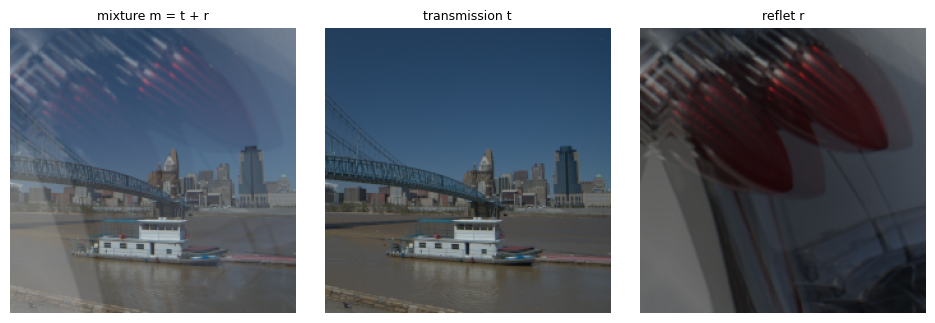

In [27]:
# Démo : on tire des paires réalistes jusqu'à trouver un mélange accepté
ex = None
for i in range(len(pool)):
    ia, ib = sample_realistic_pair(rnd)
    cand = simulate_example(pool[480], pool[i], rng, params=params_ghost, deterministic=True)
    if is_useful(cand):
        ex = cand
        break
assert ex is not None, "aucun mélange accepté — relance la cellule"
print(f"r = {pool[i]['name']} ({pool[i]['loc']}), "
      f"t = {pool[343]['name']} ({pool[343]['loc']})")
show_row([ex["m"], ex["t"], ex["r"]],
         ["mixture m = t + r", "transmission t", "reflet r"])


In [ ]:
CULL_SIZE = 224 # 256
vis_min, vis_max = 0.02, 0.2 # vis baseline = 0.08 # apr_s j'ai 0.02, 0.5

def measure(exa):
    """Toutes les quantités de tri en une passe, plus le premier critère qui échoue.
    Remplace is_useful : is_useful(ex) <=> measure(ex)["verdict"] == "ok"."""
    rs = lambda x: cv2.resize(x, (CULL_SIZE, CULL_SIZE), interpolation=cv2.INTER_AREA)
    mc, tc, rc = rs(exa["m"]), rs(exa["t"]), rs(exa["r"])
    Ym, Yt, Yr = luminance(mc), luminance(tc), luminance(rc)
    ssim_m_tt, std_m_tt = ssim_fast(mc, tc)

    d = {"ssim": ssim_m_tt, "ssim_std": std_m_tt,
         "m_mean": float(mc.mean()), "Ym": float(Ym.mean()),
         "vis": float(Yr.mean() / (Ym.mean() + 1e-8)),
         "t_std": float(Yt.std()), "r_std": float(Yr.std()),
         # pas un critere chez toi : on l'enregistre pour voir s'il apporterait qqch
         "sat_frac": float((mc.max(axis=-1) > 0.99).mean())}

    if   not 0.40 < d["ssim"] < 0.94:  d["verdict"] = "ssim"
    elif d["ssim_std"] < 0.05:         d["verdict"] = "ssim_std"
    elif d["m_mean"] >= 0.7:           d["verdict"] = "m_mean"
    elif not 0.04 < d["Ym"] < 0.4:     d["verdict"] = "exposition"
    elif not vis_min < d["vis"] < vis_max:    d["verdict"] = "visibilite"
    elif d["t_std"] < 0.015:           d["verdict"] = "t_plat"
    elif d["r_std"] < 0.008:           d["verdict"] = "r_plat"
    else:                              d["verdict"] = "ok"
    return d

def is_useful(exa):
    return measure(exa)["verdict"] == "ok"

In [25]:
def save_jpeg(path, lin_srgb, tone=False):
    img = finish(lin_srgb, tone=tone)                   # tone mapping + gamma sRGB partagés
    cv2.imwrite(str(path), img[..., ::-1],
                [cv2.IMWRITE_JPEG_QUALITY, JPEG_QUALITY])

def save_png(path, lin_srgb, tone=False):
    img = lin_srgb
    # img = finish(lin_srgb, tone=tone)          # même tone map + gamma sRGB que save_jpeg
    cv2.imwrite(str(path), img[..., ::-1],
                [cv2.IMWRITE_PNG_COMPRESSION, 3])   # 0-9 : sans perte quel que soit le niveau


In [24]:
def init_params():
    params = {}
    params["f_px"] = []
    params["theta0"] = []
    params["direction"] = []
    params["ghost_px"] = []
    params["defocus_px"] = []
    params["double_pane"] = []
    return params

def add_params(scene, params):
    for i in scene:
        params[i].append(scene[i])
    

8 min pour 48k essais avec 16 workers 5k examples

In [ ]:
import threading
from concurrent.futures import ThreadPoolExecutor
from collections import defaultdict
N_SIM_WORKERS = 20
MAX_TRIES = 200 * N_EXAMPLES

cv2.setNumThreads(1)          # else OpenCV oversubscribes under the thread pool

rows = []
state = {"saved": 0, "tried": 0}
lock = threading.Lock()
pbar = tqdm(total=N_EXAMPLES, desc="simulation")
distrib_reflection = np.zeros((len(pool)))
distrib_transmission = np.zeros((len(pool)))
nb_doublon = defaultdict(int)
params_d = init_params()
def _sim_worker(w, true_t=True):
    # one independent RNG stream per thread: Generators are NOT thread-safe
    rng_w = np.random.default_rng([SEED, w])
    rnd_w = random.Random(SEED * 1_000_003 + w)

    while True:
        with lock:
            if state["saved"] >= N_EXAMPLES or state["tried"] >= MAX_TRIES:
                return
            state["tried"] += 1

        # --- heavy part, lock-free -------------------------------------
        ia, ib = sample_realistic_pair(rnd_w)
        ex = simulate_example(pool[ia], pool[ib], rng_w)
        d = measure(ex)
        d.update(t_name=pool[ia]["name"], r_name=pool[ib]["name"],
                 t_loc=pool[ia]["loc"],   r_loc=pool[ib]["loc"])

        # --- reserve an output index, nothing more ---------------------
        with lock:
            rows.append(d)
            if d["verdict"] != "ok" or state["saved"] >= N_EXAMPLES:
                continue
            n = state["saved"]
            state["saved"] += 1
            distrib_reflection[ib] += 1
            distrib_transmission[ia] +=1
            add_params(ex["params"], params_d)
            pbar.update(1)

        # --- writing happens OUTSIDE the lock --------------------------
        stem = f"ex_{n:04d}"

        # for k in "mtr":
        #     save_png(OUT_DIR / f"{stem}_{k}.png", ex[k])
        if SAVE_LINEAR:
            del ex["params"]
            np.savez_compressed(OUT_DIR / f"{stem}.npz",
                                **{k: v.astype(np.float16) for k, v in ex.items()},
                                t_name=pool[ia]["name"], r_name=pool[ib]["name"])


with ThreadPoolExecutor(N_SIM_WORKERS) as tp:
    list(tp.map(_sim_worker, range(N_SIM_WORKERS)))     # list() -> re-raises worker errors
pbar.close()

print(f"{state['saved']} exemples acceptés sur {state['tried']} essais "
      f"({state['saved'] / max(state['tried'], 1):.0%} d'acceptation) -> {OUT_DIR}")


simulation: 100%|██████████| 15000/15000 [12:41<00:00, 19.69it/s]

15000 exemples acceptés sur 148875 essais (10% d'acceptation) -> /home/damien/data_fivek_dng/simulated_big_biaised2


In [31]:
import threading
from concurrent.futures import ThreadPoolExecutor

GROUP_DIR = OUT_DIR           
GROUP_DIR.mkdir(parents=True, exist_ok=True)

N_GROUPS     = 200     # nb de scenes transmises distinctes
K_MIN, K_MAX = 2, 6      # taille du groupe, tiree par groupe (bornes incluses)
MIN_KEPT     = 2         # un groupe a 1 membre n'a aucun interet -> jete
MAX_R_TRIES  = 6         # tentatives de reflet par membre avant d'abandonner ce membre
MAX_GROUP_TRIES = 200 * N_GROUPS
SAVE_SHARED_T = True     # sauve aussi le crop transmis brut, commun au groupe
N_SIM_WORKERS = 16
cv2.setNumThreads(1)

g_state    = {"groups": 0, "saved": 0, "tried": 0}
g_lock     = threading.Lock()
g_rows     = []
g_distrib_t = np.zeros(len(pool))
g_distrib_r = np.zeros(len(pool))
g_pbar     = tqdm(total=N_GROUPS, desc="groupes")


def _group_worker(w):
    rng_w = np.random.default_rng([SEED, 10_000 + w])
    rnd_w = random.Random(SEED * 1_000_003 + 10_000 + w)

    while True:
        with g_lock:
            if g_state["groups"] >= N_GROUPS or g_state["tried"] >= MAX_GROUP_TRIES:
                return
            g_state["tried"] += 1

        # --- ancre : tiree EXACTEMENT comme dans la cellule 54 ---------------
        ia, ib = sample_realistic_pair(rnd_w)
        t_pre  = make_t_crop(pool[ia], rng_w)

        anchor = simulate_example_k(pool[ia], pool[ib], rng_w, t_pre=t_pre)
        d = measure(anchor)
        if d["verdict"] != "ok":
            continue                      
        members = [(anchor, d, ib)]
        K = rnd_w.randint(K_MIN, K_MAX)
        for _ in range(K - 1):
            for _try in range(MAX_R_TRIES):
                jb = sample_reflection_for(ia, rnd_w)
                ex = simulate_example_k(pool[ia], pool[jb], rng_w, t_pre=t_pre)
                dk = measure(ex)
                if dk["verdict"] == "ok":
                    members.append((ex, dk, jb))
                    break                 # rejet simple : pas de biais sur p(j|i)

        if len(members) < MIN_KEPT:
            continue

        with g_lock:
            if g_state["groups"] >= N_GROUPS:
                return
            g = g_state["groups"]
            g_state["groups"] += 1
            g_state["saved"]  += len(members)
            g_distrib_t[ia]   += len(members)
            for _, dk, jb in members:
                g_distrib_r[jb] += 1
                g_rows.append({**dk, "group": g, "K": len(members),
                               "t_name": pool[ia]["name"], "r_name": pool[jb]["name"],
                               "t_loc": pool[ia]["loc"],   "r_loc": pool[jb]["loc"]})
            g_pbar.update(1)

        if SAVE_SHARED_T:
            M = XYZ_D50_TO_SRGB @ cat_matrix(pool[ia]["illum"])
            np.save(GROUP_DIR / f"grp_{g:05d}_t0.npy",
                    apply_matrix(np.asarray(t_pre[0], np.float32) / pool[ia]["e"],
                                 M).astype(np.float16))

        for k, (ex, dk, jb) in enumerate(members):
            p = ex.pop("params")
            np.savez_compressed(
                GROUP_DIR / f"ex_{g:05d}_{k:02d}.npz",
                **{key: v.astype(np.float16) for key, v in ex.items()},
                group=g, member=k,
                t_name=pool[ia]["name"], r_name=pool[jb]["name"],
                exposure=p["exposure"], theta0=p["theta0"],
                defocus_px=p["defocus_px"])


with ThreadPoolExecutor(N_SIM_WORKERS) as tp:
    list(tp.map(_group_worker, range(N_SIM_WORKERS)))
g_pbar.close()

print(f"{g_state['groups']} groupes, {g_state['saved']} exemples "
      f"({g_state['saved'] / max(g_state['groups'], 1):.2f} par groupe) -> {GROUP_DIR}")
pd.DataFrame(g_rows).to_parquet(GROUP_DIR / "trials_groups.parquet")


groupes: 100%|██████████| 200/200 [00:23<00:00,  8.61it/s]

200 groupes, 632 exemples (3.16 par groupe) -> /home/damien/data_fivek_dng/dataset_soomin


['m', 't', 'r', 'group', 'member', 't_name', 'r_name', 'exposure', 'theta0', 'defocus_px']


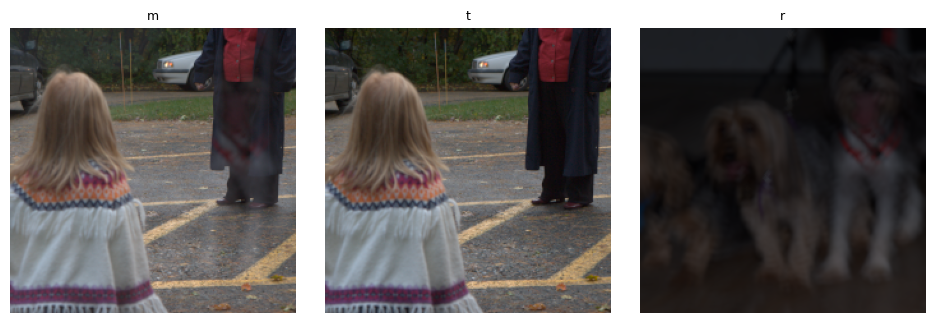

In [39]:
z = np.load(OUT_DIR / "ex_00000_00.npz")
print(z.files)                
m = z["m"].astype(np.float32)     
name = str(z["t_name"])           
show_row([m, z["t"].astype(np.float32), z["r"].astype(np.float32)], ["m", "t", "r"])

['m', 't', 'r', 'group', 'member', 't_name', 'r_name', 'exposure', 'theta0', 'defocus_px']


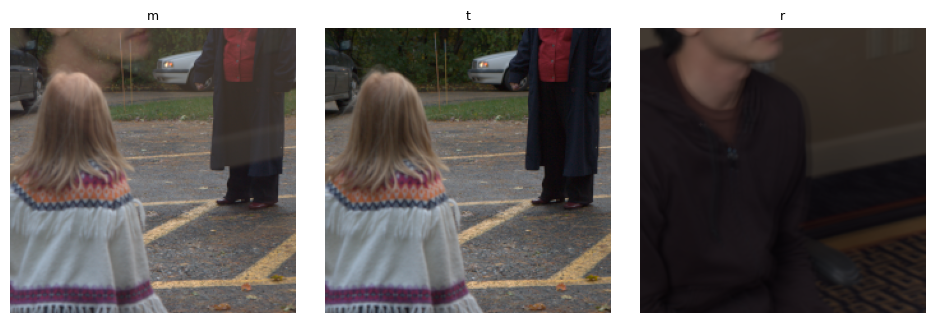

In [41]:
z = np.load(OUT_DIR / "ex_00000_01.npz")
print(z.files)                
m = z["m"].astype(np.float32)     
name = str(z["t_name"])           
show_row([m, z["t"].astype(np.float32), z["r"].astype(np.float32)], ["m", "t", "r"])

['m', 't', 'r', 'group', 'member', 't_name', 'r_name', 'exposure', 'theta0', 'defocus_px']


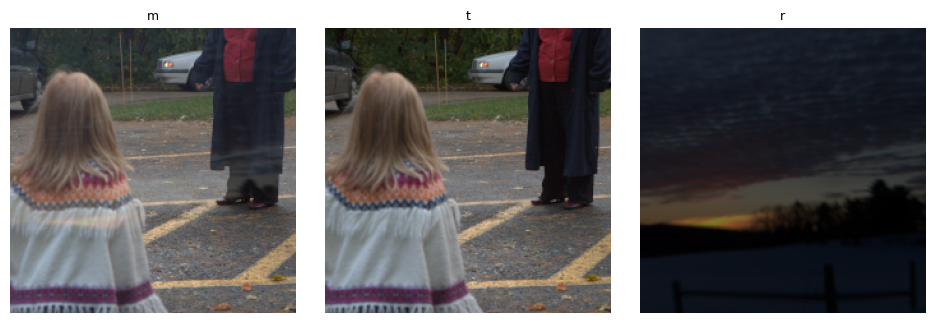

In [38]:
z = np.load(OUT_DIR / "ex_00000_02.npz")
print(z.files)                
m = z["m"].astype(np.float32)     
name = str(z["t_name"])           
show_row([m, z["t"].astype(np.float32), z["r"].astype(np.float32)], ["m", "t", "r"])

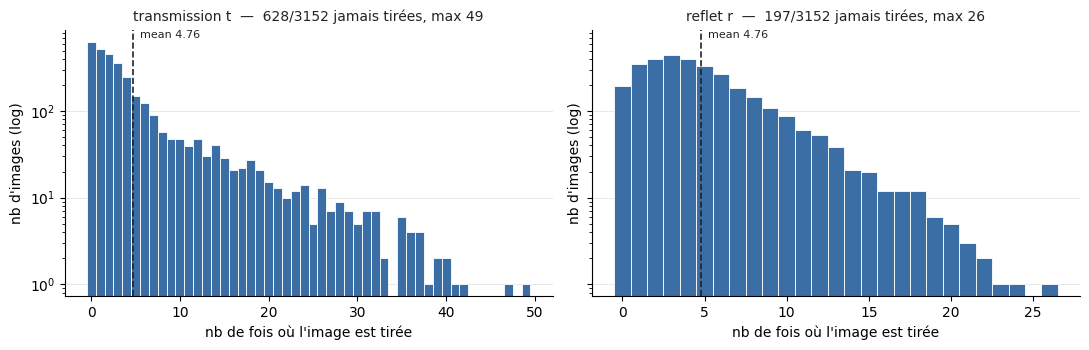

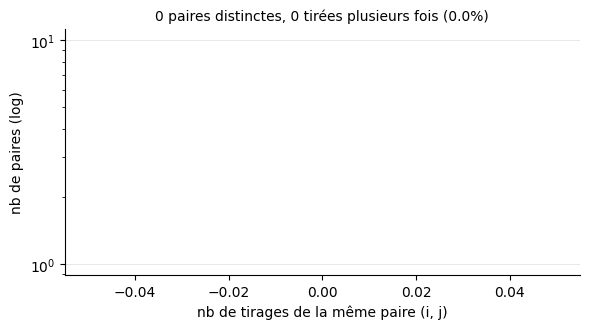

In [ ]:
# ---- diagnostics du tirage de paires ---------------------------------------
import numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

ACCENT, INK, MUTED = "#3b6ea5", "#1f2328", "#8b949e"

# 1) histogrammes des deux distributions d'usage ------------------------------
def count_hist(ax, x, title):
    x = np.asarray(x)
    bins = np.arange(int(x.max()) + 2) - 0.5      # une barre par entier
    ax.hist(x, bins=bins, color=ACCENT, edgecolor="white", linewidth=0.6)
    ax.set_yscale("log")                          # le bin 0 écrase tout le reste
    ax.axvline(x.mean(), color=INK, ls="--", lw=1.2)
    ax.text(x.mean(), ax.get_ylim()[1], f"  mean {x.mean():.2f}",
            ha="left", va="top", fontsize=8, color=INK)
    ax.set_title(f"{title}  —  {int((x == 0).sum())}/{x.size} jamais tirées, "
                 f"max {int(x.max())}", fontsize=10, color=INK)
    ax.set_xlabel("nb de fois où l'image est tirée"); ax.set_ylabel("nb d'images (log)")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color=MUTED, alpha=.25, lw=.6); ax.set_axisbelow(True)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
count_hist(axes[0], distrib_transmission, "transmission t")
count_hist(axes[1], distrib_reflection,   "reflet r")
fig.tight_layout()


# 3) doublons -----------------------------------------------------------------
d = np.fromiter(nb_doublon.values(), dtype=int, count=len(nb_doublon))
mult = np.bincount(d)
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.bar(np.arange(len(mult))[1:], mult[1:], color=ACCENT, width=.75)
for k, v in enumerate(mult):
    if k and v:
        ax.text(k, v, str(v), ha="center", va="bottom", fontsize=8, color=INK)
ax.set_yscale("log")
ax.set_title(f"{len(d)} paires distinctes, {int((d > 1).sum())} tirées plusieurs fois "
             f"({(d > 1).sum()/max(len(d),1):.1%})", fontsize=10)
ax.set_xlabel("nb de tirages de la même paire (i, j)"); ax.set_ylabel("nb de paires (log)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color=MUTED, alpha=.25, lw=.6); ax.set_axisbelow(True)
fig.tight_layout(); plt.show()

In [71]:
for i in params_d:
    params_d[i] = np.array(params_d[i])
    


f_px            n=15000  mean=185.9  std=53.99  min=112  max=307.7  median=175
theta0          n=15000  mean=0.3937  std=0.2387  min=9.732e-07  max=1.082  median=0.383
direction       [dim=(2,), aplati] n=30000  mean=0.002553  std=0.7071  min=-1  max=1  median=-0.003409
ghost_px        n=15000  mean=3.362  std=2.894  min=0.1681  max=23.09  median=2.433
defocus_px      n=15000  mean=0.5182  std=0.7311  min=4.505e-05  max=9.731  median=0.257
double_pane     n=15000  False=7634, True=7366


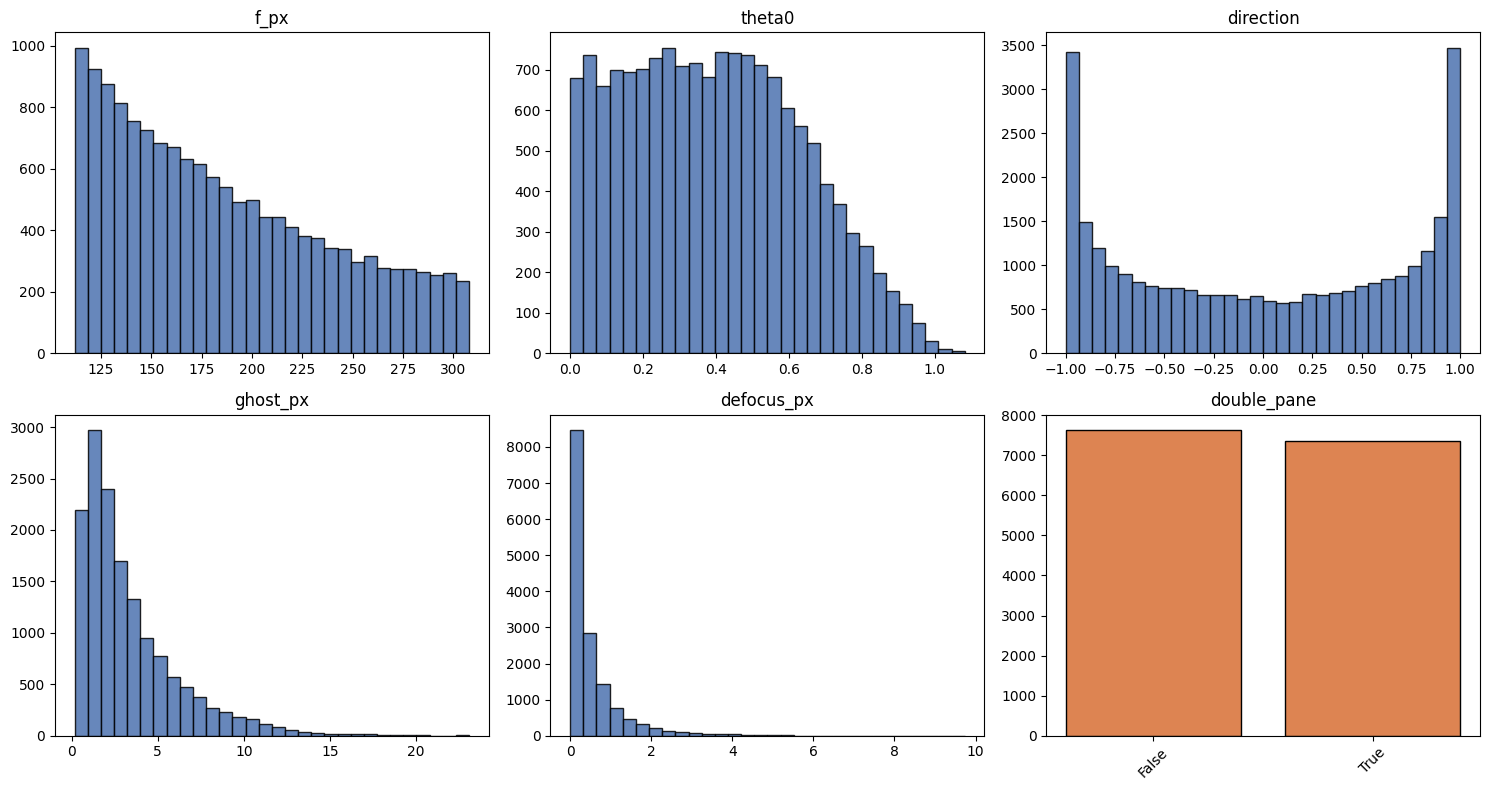

In [72]:


ncols = 3
nrows = -(-len(params_d) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = np.asarray(axes).reshape(-1)

for ax, (name, values) in zip(axes, params_d.items()):
    arr = np.asarray(values)
    if np.issubdtype(arr.dtype, np.number) or arr.dtype == bool:
        flat = arr.astype(float).ravel()
        tag = f" [dim={arr.shape[1:]}, aplati]" if arr.ndim > 1 else ""
        print(f"{name:15s}{tag} n={len(flat):5d}  mean={flat.mean():.4g}  std={flat.std():.4g}  "
              f"min={flat.min():.4g}  max={flat.max():.4g}  median={np.median(flat):.4g}")
        ax.hist(flat, bins=30, color="#4C72B0", edgecolor="black", alpha=0.85)
    else:
        cats, counts = np.unique(arr, return_counts=True)
        print(f"{name:15s} n={len(arr):5d}  " + ", ".join(f"{c}={n}" for c, n in zip(cats, counts)))
        ax.bar(cats.astype(str), counts, color="#DD8452", edgecolor="black")
        ax.tick_params(axis="x", rotation=45)
    ax.set_title(name)

for ax in axes[len(params_d):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [73]:
df = pd.DataFrame(rows)
df.to_parquet(OUT_DIR / "trials.parquet")

print(df["verdict"].value_counts(normalize=True).mul(100).round(1))
print(df.loc[df.verdict == "ok"].describe().round(4))

# ce que la fraction saturee ajouterait, si tu l'activais comme critere
ok = df.verdict == "ok"
print(f"parmi les acceptes, {(df.loc[ok, 'sat_frac'] > 0.08).mean():.1%} depassent 8% de pixels ecretes")


verdict
ssim          71.6
visibilite    13.0
ok            10.1
exposition     3.1
m_mean         2.0
r_plat         0.3
t_plat         0.0
ssim_std       0.0
Name: proportion, dtype: float64
             ssim    ssim_std      m_mean          Ym         vis       t_std  \
count  15005.0000  15005.0000  15005.0000  15005.0000  15005.0000  15005.0000   
mean       0.8263      0.1889      0.1514      0.1507      0.2512      0.1118   
std        0.0845      0.0652      0.0578      0.0578      0.0842      0.0647   
min        0.4066      0.0500      0.0734      0.0690      0.0801      0.0152   
25%        0.7749      0.1378      0.1329      0.1287      0.1827      0.0675   
50%        0.8414      0.1840      0.1329      0.1328      0.2491      0.0955   
75%        0.8954      0.2347      0.1329      0.1378      0.3220      0.1355   
max        0.9400      0.4193      0.4870      0.3999      0.4000      0.4335   

            r_std    sat_frac  
count  15005.0000  15005.0000  
mean       0.

In [68]:
def show_examples(n=3, root=None, start=0):
    """Affiche n exemples du dataset JPEG : une ligne (m | t | r | c) chacun.

    n     : nombre d'exemples à afficher
    root  : dossier des JPEG (OUT_DIR par défaut)
    start : index du premier exemple (pour paginer : show_examples(3, start=3))
    """
    root = Path(root) if root else OUT_DIR
    stems = sorted({p.name[:-6] for p in root.glob("ex_*_m.jpg")})[start:start + n]
    if not stems:
        print(f"aucun exemple trouvé dans {root}")
        return
    titles = ["mixture m", "transmission t", "reflet r", "contexte c"]
    fig, axes = plt.subplots(len(stems), 3, figsize=(13, 3.4 * len(stems)),
                             squeeze=False)
    for row, stem in zip(axes, stems):
        for ax, k, title in zip(row, "mtr", titles):
            img = cv2.imread(str(root / f"{stem}_{k}.jpg"))
            ax.imshow(img[..., ::-1])
            ax.set_title(f"{stem} — {title}", fontsize=9)
            ax.axis("off")
    plt.tight_layout()
    plt.show()

show_examples(5, start=500)


aucun exemple trouvé dans /home/damien/data_fivek_dng/simulated


In [69]:
# %pip install --quiet diffusers transformers accelerate peft

# import sys, os

# DAI_REPO = str(Path.home() / "Dereflection-Any-Image")   # pas /content : on n'est plus sur Colab
# if not os.path.isdir(DAI_REPO):
#     !git clone -q https://github.com/Abuuu122/Dereflection-Any-Image.git {DAI_REPO}
# if DAI_REPO not in sys.path:
#     sys.path.insert(0, DAI_REPO)

# # shim compat diffusers >= 0.33 (cf. fumo cellule 63)
# try:
#     import diffusers.models.controlnet  # noqa: F401
# except ModuleNotFoundError:
#     import importlib
#     sys.modules["diffusers.models.controlnet"] = importlib.import_module(
#         "diffusers.models.controlnets.controlnet")
#     print("shim: diffusers.models.controlnet -> controlnets.controlnet")

# from DAI.pipeline_all import DAIPipeline
# from DAI.controlnetvae import ControlNetVAEModel
# from DAI.decoder import CustomAutoencoderKL
# from diffusers import AutoencoderKL, UNet2DConditionModel
# from transformers import CLIPTextModel, AutoTokenizer
# import diffusers
# print("diffusers", diffusers.__version__, "- import DAI OK")


In [70]:
# device    = torch.device(DEVICE)          # DEVICE est une str dans data_clean
# DAI_ID    = "sjtu-deepvision/dereflection-any-image-v0"
# DAI_DTYPE = torch.float32

# dai_controlnet = ControlNetVAEModel.from_pretrained(DAI_ID, subfolder="controlnet", torch_dtype=DAI_DTYPE).to(device)
# dai_unet       = UNet2DConditionModel.from_pretrained(DAI_ID, subfolder="unet", torch_dtype=DAI_DTYPE).to(device)
# dai_vae2       = CustomAutoencoderKL.from_pretrained(DAI_ID, subfolder="vae_2", torch_dtype=DAI_DTYPE).to(device)
# dai_vae        = AutoencoderKL.from_pretrained(DAI_ID, subfolder="vae", torch_dtype=DAI_DTYPE).to(device)
# dai_txt        = CLIPTextModel.from_pretrained(DAI_ID, subfolder="text_encoder", torch_dtype=DAI_DTYPE).to(device)
# dai_tok        = AutoTokenizer.from_pretrained(DAI_ID, subfolder="tokenizer", use_fast=False)

# dai_pipe = DAIPipeline(
#     vae=dai_vae, text_encoder=dai_txt, tokenizer=dai_tok,
#     unet=dai_unet, controlnet=dai_controlnet,
#     safety_checker=None, scheduler=None, feature_extractor=None,
#     t_start=0,
# ).to(device)

# for m in (dai_controlnet, dai_unet, dai_vae2, dai_vae, dai_txt):
#     m.eval().requires_grad_(False)
# print("DAI prêt sur", device)


In [71]:
# def load_jpg(path):
#     """JPG disque -> [1,3,H,W] float32 dans [0,1] sur device."""
#     bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
#     if bgr is None:
#         raise FileNotFoundError(path)
#     rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
#     return torch.from_numpy(rgb).permute(2, 0, 1).unsqueeze(0).to(device)

# def psnr(pred, target, max_val=1.0):
#     mse = torch.mean((pred.float() - target.float()) ** 2)
#     return 10 * torch.log10(max_val ** 2 / mse)

# def show01(x, title=None):
#     plt.imshow(x[0].permute(1, 2, 0).float().cpu().numpy())
#     plt.axis("off")
#     if title: plt.title(title)
#     plt.show()

# @torch.no_grad()
# def dai(x01, prompt="do not remove glass reflection", processing_resolution="auto", **kw):
#     """x01: [1,3,H,W] dans [0,1] -> T_hat [1,3,H,W] dans [0,1]."""
#     if processing_resolution == "auto":
#         processing_resolution = 0 if max(x01.shape[-2:]) >= 768 else None
#     out = dai_pipe(image=x01.to(device, DAI_DTYPE), prompt=prompt, vae_2=dai_vae2,
#                    processing_resolution=processing_resolution, **kw)
#     pred = torch.from_numpy(np.asarray(out.prediction[0])).permute(2, 0, 1).unsqueeze(0).to(device)
#     return ((pred + 1) / 2).clamp(0, 1)


In [72]:
# n = 44
# M = load_jpg(OUT_DIR / f"ex_{n:04d}_m.jpg")     # mixture (avec reflet)
# T = load_jpg(OUT_DIR / f"ex_{n:04d}_t.jpg")     # transmission (GT)
# T_hat = dai(M)

# print(f"PSNR(M,T) = {psnr(M,T):.2f} dB  ->  PSNR(T_hat,T) = {psnr(T_hat,T):.2f} dB")
# show01(M, "M (entrée)"); show01(T_hat, "T_hat (DAI)"); show01(T, "T (GT)")